In [2]:
import bte
from bte import MATree, MATNode
from collections import Counter
import re
import numpy as np
from scipy.stats import multinomial
from Bio import Entrez, SeqIO
import pandas as pd
import io

In [3]:
# New updated tree with 2026 samples
tree = bte.MATree(pb_file="/Users/reem/2026_updated_tree.pb")

Finished 'from_pb' in 409.0288 seconds


In [5]:
all_nodes = list(tree.depth_first_expansion())
print(len(all_nodes))

21244182


In [6]:
print(tree.get_node("node_2172435").mutations)


['C2453T', 'T15231C', 'A24241G', 'G25660T', 'C28957T']


In [7]:
rows = []
for node in all_nodes:
    rows.append({
        "node_id": node.id,
        "parent_id": node.parent.id if node.parent else None,
        "children": [child.id for child in node.children],
        "mutations": tree.get_node(node.id).mutations,
        "num_mutations": len(tree.get_node(node.id).mutations),
        "level": node.level,
        "branch_length": node.branch_length})
df_nodes = pd.DataFrame(rows)
df_nodes.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length
0,node_1,None,[Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-0...,[],0,1,0.0
1,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],[G15910T],1,2,1.0
2,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],[G4162T],1,2,1.0
3,node_2,node_1,[England/LEED-2A8B52/2020|EPI_ISL_539074|2020-...,[T13090C],1,2,1.0
4,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"[C1191T, C11674T]",2,3,2.0


In [8]:
node = tree.get_node("node_2172435")

['C2453T', 'T15231C', 'A24241G', 'G25660T', 'C28957T']


In [10]:
df_nodes = df_nodes[df_nodes["num_mutations"] > 0]
len(df_nodes)


8943696

In [11]:
df_nodes.to_csv("/Users/reem/bte_nodes.tsv", sep="\t", index=False)

In [12]:
def mut_to_class(s):
    return re.sub(r"(\w)(\d+)(\w)", r"\1>\3", s)


def classify_mutations(muts):
    muts = [mut_to_class(m) for m in muts]
    counts = Counter(muts)
    return counts



In [13]:
# Load mutational spectra
spectra = [
    {"name":"BA.1",
     "url": "https://raw.githubusercontent.com/theosanderson/molnupiravir/main/mutational_spectra/BA.1_SBS_spectrum_Ruis.csv"
    },
    {"name":"High G-to-A",
        "url": "https://raw.githubusercontent.com/theosanderson/molnupiravir/main/mutational_spectra/long_phylogenetic_branches/long_branch_spectrum_rescaled.csv"    
    },
]

In [14]:
def fetch_reference_genome(accession='NC_045512.2'):
    Entrez.email = "theo@theo.io"  
    handle = Entrez.efetch(db="nucleotide", id=accession, rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    handle.close()
    return str(record.seq)
reference_genome = fetch_reference_genome("NC_045512.2")  # SARS-CoV-2 reference genome

In [19]:
df_nodes = pd.read_csv("/Users/reem/bte_nodes.tsv", sep="\t")

In [20]:
# Remove brackets ([]) from the mutations column and split by comma
df_nodes["mutations"] = df_nodes["mutations"].str.strip("[]")
df_nodes["mutations"]

0                                          'G15910T'
1                                           'G4162T'
2                                          'T13090C'
3                                'C1191T', 'C11674T'
4                                          'T15821C'
                             ...                    
8943691    'T1368C', 'G14071A', 'C20736T', 'C23707T'
8943692                          'G2494A', 'C18501T'
8943693                         'C24372T', 'G29779C'
8943694                          'T3931C', 'C26833T'
8943695                                    'C14621T'
Name: mutations, Length: 8943696, dtype: object

In [21]:
def get_mut_type(mut_string):
    mut_string = mut_string.strip().strip("'''").strip('"').strip("'")
    if isinstance(mut_string, str) and len(mut_string) >= 3:
        return f"{mut_string[0]}>{mut_string[-1]}"
    else:
        return ''

df_nodes["subs"]=df_nodes["mutations"].apply(lambda x: ','.join(mut for mut in (get_mut_type(item) for item in x.split(',')) if mut) if isinstance(x, str) else '')
df_nodes["subs"]

0                      G>T
1                      G>T
2                      T>C
3                  C>T,C>T
4                      T>C
                ...       
8943691    T>C,G>A,C>T,C>T
8943692            G>A,C>T
8943693            C>T,G>C
8943694            T>C,C>T
8943695                C>T
Name: subs, Length: 8943696, dtype: object

In [22]:
# Get all mutation counts
df_nodes["Counts"] = df_nodes["subs"].str.strip().apply(lambda x: dict(Counter(x.strip().split(","))))
df_nodes["Counts"].head(20)

0     {'G>T': 1}
1     {'G>T': 1}
2     {'T>C': 1}
3     {'C>T': 2}
4     {'T>C': 1}
5     {'T>C': 1}
6     {'G>T': 1}
7     {'G>T': 1}
8     {'G>A': 1}
9     {'C>T': 1}
10    {'G>T': 1}
11    {'C>T': 1}
12    {'C>T': 1}
13    {'T>C': 1}
14    {'G>A': 1}
15    {'C>T': 1}
16    {'G>A': 2}
17    {'G>A': 1}
18    {'T>C': 1}
19    {'C>T': 1}
Name: Counts, dtype: object

In [23]:
node_id = "node_2172435"
df_nodes.loc[df_nodes["node_id"] == node_id, "Counts"].values[0]

{'G>A': 11, 'A>G': 3, 'C>T': 6, 'T>C': 3, 'A>T': 1}

In [23]:
# Calculate LLR
probs_df=pd.read_csv("/Users/reem/Downloads/estimated_mutation_distribution.tsv", delimiter="\t")
pM=probs_df["Molnupiravir"].to_numpy(dtype=float)
pN=probs_df["Normal"].to_numpy(dtype=float)
mut_types=probs_df["MutationType"].str.replace("→",">").tolist()

def get_likelihood_ratio(counts,pM,pN):
    counts=np.array(counts,dtype=float)
    llM= float(multinomial.logpmf(counts, n=np.sum(counts), p=pM))
    llN = float(multinomial.logpmf(counts, n=np.sum(counts), p=pN))
    llr=llM-llN
    return llr
llr_list = []
for counts_dict in df_nodes["Counts"]:
    counts = [counts_dict.get(mt, 0) for mt in mut_types]
    llr = get_likelihood_ratio(counts,pM,pN)
    llr_list.append(llr)
df_nodes["LLR"] = llr_list
df_nodes.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],'G15910T',1,2,1.0,G>T,{'G>T': 1},-1.509730
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],'G4162T',1,2,1.0,G>T,{'G>T': 1},-1.509730
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,'T13090C',1,2,1.0,T>C,{'T>C': 1},-0.528901
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"'C1191T', 'C11674T'",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],'T15821C',1,3,1.0,T>C,{'T>C': 1},-0.528901


In [24]:
df_nodes.loc[df_nodes["node_id"] == "node_2172435", "LLR"].values[0]

np.float64(-1.3767190801427063)

In [25]:
df_nodes["mutations"].head()

0              'G15910T'
1               'G4162T'
2              'T13090C'
3    'C1191T', 'C11674T'
4              'T15821C'
Name: mutations, dtype: object

In [26]:
def get_context(genome_seq, mutation):
    # mutation must be at least ref + digits + alt
    if not isinstance(mutation, str):
        return ""
    mutation = mutation.strip().strip("'''").strip('"').strip("'")

    # must start with a nucleotide
    if mutation[0] not in "ACGT":
        return ""

    # must end with a nucleotide
    if mutation[-1] not in "ACGT":
        return ""

    # extract numeric middle part
    middle = mutation[1:-1]
    if not middle.isdigit():
        return ""
    pos = int(middle) - 1
    context = genome_seq[pos-1:pos+2]  # get the base before and after
    return context
df_nodes["context"] = df_nodes["mutations"].apply(lambda x: ','.join(mut for mut in (get_context(reference_genome, item) for item in x.split(',')) if mut) if isinstance(x, str) else '')
df_nodes["context"]


0                      TGA
1                      TGG
2                      ATG
3                  CCA,ACT
4                      ATG
                ...       
8943691    ATT,AGA,ACC,CCA
8943692            AGG,ACA
8943693            TCA,GGA
8943694            TTG,GCG
8943695                ACG
Name: context, Length: 8943696, dtype: object

In [27]:
def spectrum(subs, contexts):
    if not isinstance(subs, str) or not isinstance(contexts, str):
        return ''
    if not subs.strip() or not contexts.strip():
        return ''
    subs= [s.strip() for s in subs.split(',')]
    contexts = [c.strip() for c in contexts.split(',')]
    spectra = []
    for mutation, context in zip(subs, contexts): 
        if len(context) >= 2 and mutation:
            spectra.append(f"{context[0]}[{mutation}]{context[-1]}")
        else:
            continue
    return ','.join(spectra)
df_nodes["spectrum"] = df_nodes.apply(lambda row: spectrum(row["subs"], row["context"]), axis=1)
df_nodes["spectrum"].head(20)

0             T[G>T]A
1             T[G>T]G
2             A[T>C]G
3     C[C>T]A,A[C>T]T
4             A[T>C]G
5             T[T>C]T
6             T[G>T]A
7             C[G>T]T
8             A[G>A]T
9             C[C>T]C
10            A[G>T]T
11            C[C>T]C
12            A[C>T]C
13            G[T>C]T
14            A[G>A]T
15            T[C>T]T
16    A[G>A]C,A[G>A]C
17            A[G>A]G
18            T[T>C]T
19            A[C>T]G
Name: spectrum, dtype: object

In [28]:
def count_GtoA(spectrum):
    counts = Counter()
    muts = spectrum.split(",")
    for mut in muts:
        if mut[2:5] == 'G>A':
            counts[mut]+=1
    return counts
df_nodes["GtoA_counts"] = df_nodes["spectrum"].apply(count_GtoA)
df_nodes["GtoA_counts"].head(20)

0                 {}
1                 {}
2                 {}
3                 {}
4                 {}
5                 {}
6                 {}
7                 {}
8     {'A[G>A]T': 1}
9                 {}
10                {}
11                {}
12                {}
13                {}
14    {'A[G>A]T': 1}
15                {}
16    {'A[G>A]C': 2}
17    {'A[G>A]G': 1}
18                {}
19                {}
Name: GtoA_counts, dtype: object

In [29]:
#Calculate G>A LLRS using prob_table:

probs_df=pd.read_csv("/Users/reem/G>Aprobs_new.tsv", delimiter="\t")
pM=probs_df["Molnupiravir"].to_numpy(dtype=float)
pN=probs_df["Normal"].to_numpy(dtype=float)
mut_types=probs_df["Mutational_Context"].tolist()

def get_likelihood_ratio(counts,pM,pN):
    counts=np.array(counts,dtype=float)
    llM= float(multinomial.logpmf(counts, n=np.sum(counts), p=pM))
    llN = float(multinomial.logpmf(counts, n=np.sum(counts), p=pN))
    llr=llM-llN
    return llr
llr_list = []
for counts_dict in df_nodes["GtoA_counts"]:
    counts = [counts_dict.get(mt, 0) for mt in mut_types]
    llr = get_likelihood_ratio(counts,pM,pN)
    llr_list.append(llr)
df_nodes["G>A_llr"] = llr_list
df_nodes.head()

print(df_nodes[f"G>A_llr"].head())

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: G>A_llr, dtype: float64


In [30]:
def count_AtoG(spectrum):   # spectrum eg. "C[A>G]T,T[C>T]G"
    counts = Counter()
    muts = spectrum.split(",")
    for mut in muts:
        if mut[2:5] == 'A>G':
            counts[mut]+=1
    return counts
df_nodes["AtoG_counts"] = df_nodes["spectrum"].apply(count_AtoG)
df_nodes["AtoG_counts"].head(20)

0     {}
1     {}
2     {}
3     {}
4     {}
5     {}
6     {}
7     {}
8     {}
9     {}
10    {}
11    {}
12    {}
13    {}
14    {}
15    {}
16    {}
17    {}
18    {}
19    {}
Name: AtoG_counts, dtype: object

In [31]:
probs_df=pd.read_csv("/Users/reem/A>Gprobs_new.tsv", delimiter="\t")
pM=probs_df["Molnupiravir"].to_numpy(dtype=float)
pN=probs_df["Normal"].to_numpy(dtype=float)
mut_types=probs_df["Mutational_Context"].tolist()

def get_likelihood_ratio(counts,pM,pN):
    counts=np.array(counts,dtype=float)
    llM= float(multinomial.logpmf(counts, n=np.sum(counts), p=pM))
    llN = float(multinomial.logpmf(counts, n=np.sum(counts), p=pN))
    llr=llM-llN
    return llr
llr_list = []
for counts_dict in df_nodes["AtoG_counts"]:
    counts = [counts_dict.get(mt, 0) for mt in mut_types]
    llr = get_likelihood_ratio(counts,pM,pN)
    llr_list.append(llr)
df_nodes["A>G_llr"] = llr_list
df_nodes.head()

print(df_nodes[f"A>G_llr"])

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
8943691    0.0
8943692    0.0
8943693    0.0
8943694    0.0
8943695    0.0
Name: A>G_llr, Length: 8943696, dtype: float64


In [32]:
def count_CtoT(spectrum):
    counts = Counter()
    muts = spectrum.split(",")
    for mut in muts:
        if mut[2:5] == 'C>T':
            counts[mut]+=1
    return counts
df_nodes["CtoT_counts"] = df_nodes["spectrum"].apply(count_CtoT)
df_nodes["CtoT_counts"].head(20)

0                               {}
1                               {}
2                               {}
3     {'C[C>T]A': 1, 'A[C>T]T': 1}
4                               {}
5                               {}
6                               {}
7                               {}
8                               {}
9                   {'C[C>T]C': 1}
10                              {}
11                  {'C[C>T]C': 1}
12                  {'A[C>T]C': 1}
13                              {}
14                              {}
15                  {'T[C>T]T': 1}
16                              {}
17                              {}
18                              {}
19                  {'A[C>T]G': 1}
Name: CtoT_counts, dtype: object

In [33]:
probs_df=pd.read_csv("/Users/reem/C>Tprobs_new.tsv", delimiter="\t")
pM=probs_df["Molnupiravir"].to_numpy(dtype=float)
pN=probs_df["Normal"].to_numpy(dtype=float)
mut_types=probs_df["Mutational_Context"].tolist()

def get_likelihood_ratio(counts,pM,pN):
    counts=np.array(counts,dtype=float)
    llM= float(multinomial.logpmf(counts, n=np.sum(counts), p=pM))
    llN = float(multinomial.logpmf(counts, n=np.sum(counts), p=pN))
    llr=llM-llN
    return llr
llr_list = []
for counts_dict in df_nodes["CtoT_counts"]:
    counts = [counts_dict.get(mt, 0) for mt in mut_types]
    llr = get_likelihood_ratio(counts,pM,pN)
    llr_list.append(llr)
df_nodes["C>T_llr"] = llr_list
df_nodes.head()

print(df_nodes[f"C>T_llr"])

0          0.000000
1          0.000000
2          0.000000
3         -0.351044
4          0.000000
             ...   
8943691   -0.241789
8943692    0.340455
8943693    0.100023
8943694    0.198647
8943695   -0.404151
Name: C>T_llr, Length: 8943696, dtype: float64


In [34]:
def count_TtoC(spectrum):
    counts = Counter()
    muts = spectrum.split(",")
    for mut in muts:
        if mut[2:5] == 'T>C':
            counts[mut]+=1
    return counts
df_nodes["TtoC_counts"] = df_nodes["spectrum"].apply(count_TtoC)
df_nodes["TtoC_counts"].head(20)

0                 {}
1                 {}
2     {'A[T>C]G': 1}
3                 {}
4     {'A[T>C]G': 1}
5     {'T[T>C]T': 1}
6                 {}
7                 {}
8                 {}
9                 {}
10                {}
11                {}
12                {}
13    {'G[T>C]T': 1}
14                {}
15                {}
16                {}
17                {}
18    {'T[T>C]T': 1}
19                {}
Name: TtoC_counts, dtype: object

In [35]:
probs_df=pd.read_csv("/Users/reem/T>Cprobs_new.tsv", delimiter="\t")
pM=probs_df["Molnupiravir"].to_numpy(dtype=float)
pN=probs_df["Normal"].to_numpy(dtype=float)
mut_types=probs_df["Mutational_Context"].tolist()

def get_likelihood_ratio(counts,pM,pN):
    counts=np.array(counts,dtype=float)
    llM= float(multinomial.logpmf(counts, n=np.sum(counts), p=pM))
    llN = float(multinomial.logpmf(counts, n=np.sum(counts), p=pN))
    llr=llM-llN
    return llr
llr_list = []
for counts_dict in df_nodes["TtoC_counts"]:
    counts = [counts_dict.get(mt, 0) for mt in mut_types]
    llr = get_likelihood_ratio(counts,pM,pN)
    llr_list.append(llr)
df_nodes["T>C_llr"] = llr_list
df_nodes.head()

print(df_nodes[f"T>C_llr"])

0          0.000000
1          0.000000
2         -0.356234
3          0.000000
4         -0.356234
             ...   
8943691   -0.292375
8943692    0.000000
8943693    0.000000
8943694    0.565240
8943695    0.000000
Name: T>C_llr, Length: 8943696, dtype: float64


In [36]:
df_nodes["sum_llrs"] = df_nodes["LLR"] + df_nodes["G>A_llr"] + df_nodes["A>G_llr"] + df_nodes["C>T_llr"] + df_nodes["T>C_llr"]
df_nodes.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,spectrum,GtoA_counts,G>A_llr,AtoG_counts,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],'G15910T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,T[G>T]A,{},0.0,{},0.0,{},0.000000,{},0.000000,-1.509730
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],'G4162T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,T[G>T]G,{},0.0,{},0.0,{},0.000000,{},0.000000,-1.509730
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,'T13090C',1,2,1.0,T>C,{'T>C': 1},-0.528901,...,A[T>C]G,{},0.0,{},0.0,{},0.000000,{'A[T>C]G': 1},-0.356234,-0.885135
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"'C1191T', 'C11674T'",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,"C[C>T]A,A[C>T]T",{},0.0,{},0.0,"{'C[C>T]A': 1, 'A[C>T]T': 1}",-0.351044,{},0.000000,0.521315
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],'T15821C',1,3,1.0,T>C,{'T>C': 1},-0.528901,...,A[T>C]G,{},0.0,{},0.0,{},0.000000,{'A[T>C]G': 1},-0.356234,-0.885135


In [41]:
df_nodes["sum_contexts"] = df_nodes["G>A_llr"] + df_nodes["A>G_llr"] + df_nodes["C>T_llr"] + df_nodes["T>C_llr"]
df_nodes.head() 

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,GtoA_counts,G>A_llr,AtoG_counts,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],'G15910T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,{},0.0,{},0.0,{},0.000000,{},0.000000,-1.509730,0.000000
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],'G4162T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,{},0.0,{},0.0,{},0.000000,{},0.000000,-1.509730,0.000000
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,'T13090C',1,2,1.0,T>C,{'T>C': 1},-0.528901,...,{},0.0,{},0.0,{},0.000000,{'A[T>C]G': 1},-0.356234,-0.885135,-0.356234
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"'C1191T', 'C11674T'",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,{},0.0,{},0.0,"{'C[C>T]A': 1, 'A[C>T]T': 1}",-0.351044,{},0.000000,0.521315,-0.351044
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],'T15821C',1,3,1.0,T>C,{'T>C': 1},-0.528901,...,{},0.0,{},0.0,{},0.000000,{'A[T>C]G': 1},-0.356234,-0.885135,-0.356234


In [42]:
df_nodes.to_csv("/Users/reem/bte_26_sumllrs.tsv", sep="\t", index=False)

In [7]:
df_nodes = pd.read_csv("/Users/reem/bte_26_sumllrs.tsv", sep="\t")

In [4]:
# Merge metafitch output with bte output to get metadata for the nodes in the tree
metafitch_out = pd.read_csv("/Users/reem/merged_metafitch.tsv", sep = "\t")

In [6]:
metafitch_out.rename(columns={"strain": "node_id"}, inplace=True)


In [8]:
# Merge metafitch output with bte output on bte_nodes
merged = pd.merge(df_nodes, metafitch_out, on="node_id", how="left")
merged.head()


,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,AtoG_counts,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],'G15910T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,Counter(),0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,China,2020
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],'G4162T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,Counter(),0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,NaN,2020
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,'T13090C',1,2,1.0,T>C,{'T>C': 1},-0.528901,...,Counter(),0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"'C1191T', 'C11674T'",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,Counter(),0.0,"Counter({'C[C>T]A': 1, 'A[C>T]T': 1})",-0.351044,Counter(),0.000000,0.521315,-0.351044,England,2020
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],'T15821C',1,3,1.0,T>C,{'T>C': 1},-0.528901,...,Counter(),0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020


In [9]:
len(merged)

8943696

In [10]:
def get_descendant_leaves(root_node):
    """
    Return all leaf sample IDs below an internal node.
    """
    leaves =[]
    stack = [root_node]
    while stack:
        node = stack.pop()

        if len(node.children) == 0:
            leaves.append(node.id)
            continue
        for child_id in node.children:
            child_node = child_id
            stack.append(child_node)
    return leaves

In [11]:
def get_parent_id(node):
    if node.parent:
        return node.parent.id if isinstance(node.parent, MATNode) else node.parent
    else:
        return None

In [12]:
merged["num_descendants"] = merged["node_id"].apply(lambda n: len(get_descendant_leaves(tree.get_node(n))))
merged.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],'G15910T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,China,2020,1
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],'G4162T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,NaN,2020,1
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,'T13090C',1,2,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,2
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"'C1191T', 'C11674T'",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,0.0,"Counter({'C[C>T]A': 1, 'A[C>T]T': 1})",-0.351044,Counter(),0.000000,0.521315,-0.351044,England,2020,1
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],'T15821C',1,3,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,1


In [13]:
# SAVE FINAL OUTPUT
merged.to_csv("/Users/reem/merged_bte_final.tsv", sep = "\t",index=False)

In [14]:
mov_nodes = merged[(merged["LLR"] > 3) & (merged["sum_contexts"] > 2)]

mov_cluster_roots = []                                  # A cluster root is a node that is in mov_nodes but its parent is not in mov_nodes (or it has no parent)
                                                        # To avoid nested clusters and double counting
for node in tree.depth_first_expansion():
    if node.id not in mov_nodes["node_id"].values:
        continue
    parent_id = get_parent_id(node)
    if parent_id is None or parent_id not in mov_nodes["node_id"].values:
        mov_cluster_roots.append(node.id)
                                                            
print(len(mov_cluster_roots))
print(mov_cluster_roots)


995
['Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|2021-11-04', 'India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708373|2020-09-28', 'Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|2020-09-22', 'USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021-04-19', 'hCoV-19/Australia/WA6668/2022|2022-08-19|2022-09-06', 'node_546047', 'hCoV-19/USA/MN-CDC-IBX024513492461/2022|2022-01-31|2022-02-17', 'Denmark/DCGC-369053/2022|EPI_ISL_10012883|2022-02-08', 'Denmark/DCGC-651260/2022|EPI_ISL_18152107|2022-01-31', 'Australia/VIC46621/2022|EPI_ISL_11630027|2022-03-07', 'England/NORT-YNNJM4E/2022|OY887762.1|2022-03-09', 'England/PLYM-342FAF1/2022|EPI_ISL_9367297|2022-01-24', 'hCoV-19/England/PHEC-YY8Y3RA/2022|2022-09-28|2022-10-17', 'node_582829', 'England/MILK-341735B/2022|EPI_ISL_9382677|2022-01-23', 'hCoV-19/England/NORT-YNB369M/2022|2022|2022-02-22', 'England/QEUH-33ABAA3/2022|EPI_ISL_9292221|2022-01-21', 'hCoV-19/England/PHEP-YYRBE9U/2022|2022-01-25|2022-02-16', 'hCoV-19/Germany/BY-LGL-IMS-10272-CVDP-d009e932-468

In [18]:
mov_relaxed = merged[merged["sum_llrs"] > 6]
mov_ids = set(mov_relaxed["node_id"])

mov_cluster = []

for node in tree.depth_first_expansion():
    if node.id not in mov_ids:
        continue
    parent_id = get_parent_id(node)
    if parent_id is None or parent_id not in mov_ids:
        mov_cluster.append(node.id)
                                                            
print(len(mov_cluster))
print(mov_cluster)

1210
['Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|2021-11-04', 'node_143150', 'USA/NC-CORVASEQ-DH-182M245000001406/2021|OL866144.1|2021-07-02', 'Turkey/HSGM-B3574/2021|EPI_ISL_2968466|2021-03-30', 'hCoV-19/Ecuador/INSPI-M1A/2020|2020-11-24|2022-04-22', 'India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708373|2020-09-28', 'Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|2020-09-22', 'deer/USA/NY-WTD_165681/2021|EPI_ISL_13658809|2021-11-20', 'node_331403', 'node_359830', 'hCoV-19/Australia/WA6668/2022|2022-08-19|2022-09-06', 'node_546047', 'England/ARCH-002550F9/2022|OY964502.1|2022-01-12', 'hCoV-19/USA/MN-CDC-IBX024513492461/2022|2022-01-31|2022-02-17', 'Denmark/DCGC-369053/2022|EPI_ISL_10012883|2022-02-08', 'Denmark/DCGC-369124/2022|EPI_ISL_10013073|2022-02-09', 'Denmark/DCGC-651260/2022|EPI_ISL_18152107|2022-01-31', 'Australia/VIC46621/2022|EPI_ISL_11630027|2022-03-07', 'England/NORT-YNNJM4E/2022|OY887762.1|2022-03-09', 'England/PLYM-342FAF1/2022|EPI_ISL_9367297|2022-01-24', 'hCoV-19/England/

In [15]:
cluster_df = pd.DataFrame({
    "node_id": mov_cluster_roots,
    "cluster_size": [len(get_descendant_leaves(tree.get_node(n))) for n in mov_cluster_roots]})
len(cluster_df)

995

In [19]:
cluster = pd.DataFrame({
    "node_id": mov_cluster,
    "cluster_size": [len(get_descendant_leaves(tree.get_node(n))) for n in mov_cluster]})
len(cluster)

1210

In [16]:
# Merge cluster sizes back to mov_nodes
mov_nodes = pd.merge(mov_nodes, cluster_df, on="node_id", how="left")
mov_nodes.head()


,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants,cluster_size
0,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,node_24835,[],"'C1758T', 'C7600T', 'G8984A', 'C11200T', 'C166...",13,26,13.0,"C>T,C>T,G>A,C>T,C>T,C>T,C>T,C>T,C>T,C>T,C>T,T>...","{'C>T': 11, 'G>A': 1, 'T>C': 1}",4.774250,...,"Counter({'A[C>T]T': 4, 'G[C>T]A': 3, 'C[C>T]A'...",0.909696,Counter({'C[T>C]T': 1}),0.833280,7.027866,2.253616,Tanzania,2021,1,1.0
1,India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708...,node_243043,[],"'C8299T', 'C10369T', 'C10714T', 'C12528T', 'C1...",9,13,9.0,"C>T,C>T,C>T,C>T,C>T,C>T,C>T,C>T,C>T",{'C>T': 9},3.925618,...,"Counter({'A[C>T]A': 3, 'G[C>T]A': 2, 'T[C>T]A'...",2.676172,Counter(),0.000000,6.601791,2.676172,India,2020,1,1.0
2,Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...,node_243370,[],"'C676T', 'C1387T', 'C5986T', 'G8990A', 'C9487T...",10,14,10.0,"C>T,C>T,C>T,G>A,C>T,C>T,T>C,G>A,G>A,G>A","{'C>T': 5, 'G>A': 4, 'T>C': 1}",3.672689,...,"Counter({'A[C>T]A': 2, 'G[C>T]G': 1, 'T[C>T]A'...",0.710646,Counter({'A[T>C]T': 1}),-0.292375,6.405349,2.732660,Mexico,2020,1,1.0
3,USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021...,node_254525,[],"'C2110T', 'C6954T', 'T7984C', 'C8809T', 'C8890...",10,24,10.0,"C>T,C>T,T>C,C>T,C>T,C>T,C>T,C>T,G>A,C>T","{'C>T': 8, 'T>C': 1, 'G>A': 1}",3.465710,...,"Counter({'A[C>T]A': 4, 'A[C>T]T': 2, 'G[C>T]A'...",1.894295,Counter({'A[T>C]C': 1}),-0.564183,5.982177,2.516467,USA,2021,1,1.0
4,hCoV-19/Australia/WA6668/2022|2022-08-19|2022-...,node_543775,[],"'G428A', 'G1156A', 'C1282T', 'G1358A', 'T1792C...",61,37,61.0,"G>A,G>A,C>T,G>A,T>C,C>T,A>G,C>T,G>A,G>A,C>T,G>...","{'G>A': 17, 'C>T': 26, 'T>C': 7, 'A>G': 7, 'C>...",9.789147,...,"Counter({'A[C>T]A': 11, 'T[C>T]A': 3, 'C[C>T]A...",3.732134,"Counter({'C[T>C]T': 2, 'T[T>C]A': 1, 'A[T>C]A'...",1.886101,21.424638,11.635491,Australia,2022,1,1.0


In [20]:
# Merge cluster sizes back to mov_nodes
mov_relaxed = pd.merge(mov_relaxed, cluster, on="node_id", how="left")
mov_relaxed.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants,cluster_size
0,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,node_24835,[],"'C1758T', 'C7600T', 'G8984A', 'C11200T', 'C166...",13,26,13.0,"C>T,C>T,G>A,C>T,C>T,C>T,C>T,C>T,C>T,C>T,C>T,T>...","{'C>T': 11, 'G>A': 1, 'T>C': 1}",4.774250,...,"Counter({'A[C>T]T': 4, 'G[C>T]A': 3, 'C[C>T]A'...",0.909696,Counter({'C[T>C]T': 1}),0.833280,7.027866,2.253616,Tanzania,2021,1,1.0
1,node_143150,node_143148,['USA/PA-0258/2021|EPI_ISL_10657990|2021-07-23...,"'C5183T', 'C5365T', 'C6813T', 'C7029T', 'C7279...",23,17,23.0,"C>T,C>T,C>T,C>T,C>T,G>A,C>T,C>T,C>T,C>T,C>T,C>...","{'C>T': 19, 'G>A': 3, 'A>T': 1}",8.293204,...,"Counter({'A[C>T]A': 5, 'T[C>T]T': 5, 'T[C>T]A'...",-1.220422,Counter(),0.000000,8.094339,-0.198865,USA,2021,2,2.0
2,USA/NC-CORVASEQ-DH-182M245000001406/2021|OL866...,node_153531,[],"'C337T', 'G3527A', 'C3768T', 'C3902T', 'C6720T...",20,19,20.0,"C>T,G>A,C>T,C>T,C>T,C>T,C>A,C>T,G>A,C>T,G>A,C>...","{'C>T': 15, 'G>A': 4, 'C>A': 1}",7.276801,...,"Counter({'A[C>T]T': 5, 'A[C>T]A': 3, 'T[C>T]T'...",0.785146,Counter(),0.000000,7.105877,-0.170924,USA,2021,1,1.0
3,Turkey/HSGM-B3574/2021|EPI_ISL_2968466|2021-03-30,node_157667,[],"'C2462T', 'A3058G', 'A4595G', 'A9235G', 'G1185...",16,8,16.0,"C>T,A>G,A>G,A>G,G>A,T>C,C>T,A>G,G>A,G>A,C>T,G>...","{'C>T': 4, 'A>G': 5, 'G>A': 5, 'T>C': 2}",2.160544,...,"Counter({'T[C>T]T': 1, 'C[C>T]A': 1, 'A[C>T]A'...",-0.028852,"Counter({'T[T>C]T': 1, 'A[T>C]G': 1})",0.272025,6.762409,4.601865,Turkey,2021,1,1.0
4,hCoV-19/Ecuador/INSPI-M1A/2020|2020-11-24|2022...,node_226010,[],"'C2306T', 'C5400T', 'C6730T', 'G6894A', 'T7689...",22,11,22.0,"C>T,C>T,C>T,G>A,T>C,C>T,T>C,G>A,G>A,T>C,C>T,T>...","{'C>T': 9, 'G>A': 7, 'T>C': 3, 'T>A': 2, 'A>G'...",2.953517,...,"Counter({'G[C>T]T': 2, 'A[C>T]A': 2, 'A[C>T]T'...",0.059489,"Counter({'C[T>C]T': 2, 'C[T>C]A': 1})",1.415978,7.903479,4.949961,Ecuador,2020,1,1.0


In [17]:
mov_nodes.to_csv("merged_bte_mov_strict.tsv", sep = "\t", index=False)


In [21]:
mov_relaxed.to_csv("merged_bte_mov_relaxed.tsv", sep = "\t", index=False)

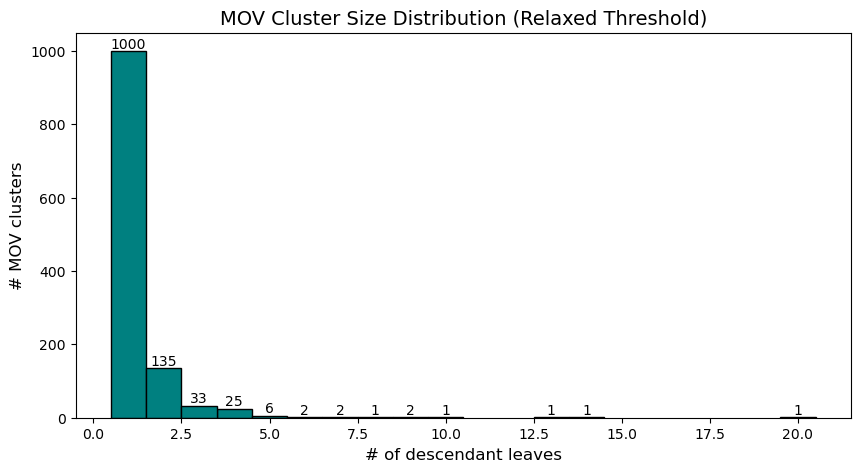

<Figure size 640x480 with 0 Axes>

In [22]:
# Repeat the figure but with crude threshold MOV clusters instead of strict threshold MOV clusters

mov_relaxed = pd.read_csv("merged_bte_mov_relaxed.tsv", sep="\t")

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np                  

# size counts
size_counts = Counter(mov_relaxed["cluster_size"])

sizes = size_counts.keys()
counts = size_counts.values()

plt.figure(figsize=(10,5))

bars = plt.bar(
    sizes,
    counts,
    width=1.0,
    color="teal",
    edgecolor="black"
)
x_values = np.arange(len(sizes))
plt.xlabel("# of descendant leaves", fontsize=12)
plt.ylabel("# MOV clusters", fontsize=12)
plt.title("MOV Cluster Size Distribution (Relaxed Threshold)", fontsize=14)

ax = plt.gca()
ax.bar_label(bars, label_type='edge', color='black')
plt.show()

plt.tight_layout()
plt.show()

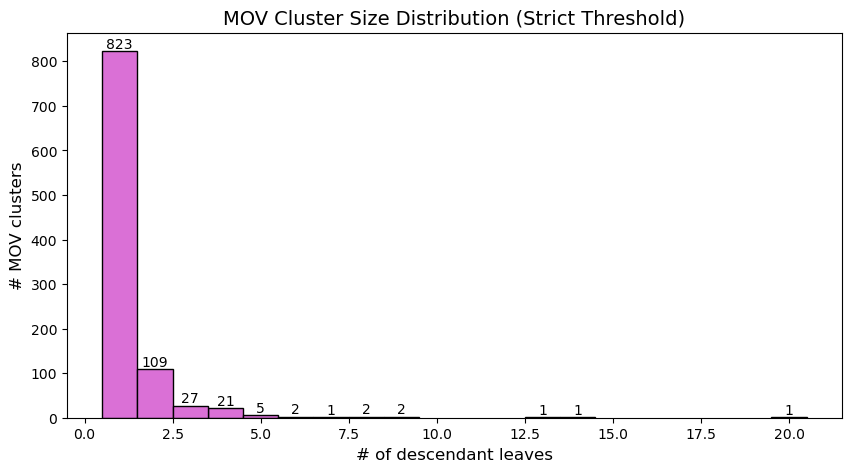

<Figure size 640x480 with 0 Axes>

In [23]:
# strict threshold MOV clusters

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

strict_mov_nodes = pd.read_csv("merged_bte_mov_strict.tsv", sep="\t")


# size counts
size_counts = Counter(strict_mov_nodes["cluster_size"])

sizes = size_counts.keys()
counts = size_counts.values()

plt.figure(figsize=(10,5))

bars = plt.bar(
    sizes,
    counts,
    width=1.0,
    color="orchid",
    edgecolor="black"
)
x_values = np.arange(len(sizes))
plt.xlabel("# of descendant leaves", fontsize=12)
plt.ylabel("# MOV clusters", fontsize=12)
plt.title("MOV Cluster Size Distribution (Strict Threshold)", fontsize=14)

ax = plt.gca()
ax.bar_label(bars, label_type='edge', color='black')
plt.show()

plt.tight_layout()
plt.show()
